In [1]:

import multiprocessing

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm


/home/ritaferi/pymc-env/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================
FILES = {
    "50d": {
        "path": "csv-files/zro2_white&green_ 50_days.csv",
        "time": 4279386,
        "calibration": {
            "a": 0.357304,
            "b": -0.295444,
            "c": 1.352297e-9,
        },
    },
    "30d": {
        "path": "csv-files/new_data.csv",
        "time": 2827661,
        "calibration": {
            "a": 0.4142675,
            "b": 2.78,
            "c": 8.4771e-7,
        },
    },
}

In [4]:
ENERGY_RANGE = (0, 3000)
BIN_WIDTH = 0.4

BACKGROUND_PEAKS = {
   "???" : 860,
    "207Tl": 897.77,
    "228Ac": 911.204,
}

FIT_WINDOW = 5

SIGNAL = {
    "mu": 871,
    "roi": (845, 920),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [5]:
# ============================================================
# ENERGY RESOLUTION
# ============================================================
def sigma_fun(E):
    """
    Detector energy resolution model.
    Returns sigma in keV.
    """
    A = 3.68436e1
    B = 1.72714e4

    return (E * np.sqrt(A / E + B / E**2)) / 2.355 / 100
    


In [6]:

# ============================================================
# DATA LOADING
# ============================================================
def load_spectrum(file_path, calibration, energy_range=(0, 3000)):
    """
    Load raw spectrum and convert channels to energy.
    """

    data = pd.read_csv(file_path, header=None)
    spectrum = data[0].to_numpy(dtype=np.float64)

    channels = np.arange(len(spectrum))

    E = (
        channels * calibration["a"]
        + calibration["b"]
        + calibration["c"] * channels**2
    )

    mask = (E >= energy_range[0]) & (E <= energy_range[1])

    return E[mask], spectrum[mask]

In [7]:
# ============================================================
# HISTOGRAMMING
# ============================================================
def make_histogram(E, spectrum, bins):
    counts, edges = np.histogram(E, bins=bins, weights=spectrum)
    centers = 0.5 * (edges[1:] + edges[:-1])

    return centers, counts



In [8]:

# ============================================================
# GAUSSIAN MODEL
# ============================================================
def gaussian_plus_bg(E, mu, sigma, area, background):
    """
    Gaussian normalized to total area + flat background.
    """

    gaussian = (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((E - mu) / sigma) ** 2)
    )

    return gaussian + background


In [9]:
# ============================================================
# PEAK FITTING
# ============================================================
def fit_peak(E, counts, center, window=4, plot=True):
    """
    Fit a Gaussian peak + constant background.
    """

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    sigma_guess = sigma_fun(center)

    p0 = [
        center,
        sigma_guess,
        np.sum(counts_roi),
        np.median(counts_roi),
    ]

    bounds = (
        [center - 1, 0.01, 0, 0],
        [center + 1, 10, np.inf, np.inf],
    )

    popt, pcov = curve_fit(
        gaussian_plus_bg,
        E_roi,
        counts_roi,
        p0=p0,
        bounds=bounds,
        #sigma=np.sqrt(counts_roi),
        maxfev=10000,
    )

    perr = np.sqrt(np.diag(pcov))

    result = {
        "mu": popt[0],
        "sigma": popt[1],
        "N": popt[2],
        "B": popt[3],
        "err_mu": perr[0],
        "err_sigma": perr[1],
        "err_N": perr[2],
        "err_B": perr[3],
    }

    if plot:
        fig, ax = plt.subplots(
            2,
            1,
            figsize=(7, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 400)
        model_fit = gaussian_plus_bg(E_fit, *popt)

        ax[0].step(E_roi, counts_roi, where="mid", color="black", label="Data")
        ax[0].plot(E_fit, model_fit, color="red", lw=2, label="Fit")

        ax[0].set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
        ax[0].set_title(f"Peak @ {center:.2f} keV")
        ax[0].legend()
        ax[0].grid(alpha=0.3)

        residuals = counts_roi - gaussian_plus_bg(E_roi, *popt)

        ax[1].scatter(E_roi, residuals, s=15)
        ax[1].axhline(0, color="red")
        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result


In [10]:

# ============================================================
# BUILD TOTAL DATASET
# ============================================================
def build_total_spectrum(files_config, bins):
    all_histograms = []
    total_time = 0

    for key, cfg in files_config.items():
        E, spectrum = load_spectrum(
            cfg["path"],
            cfg["calibration"],
            ENERGY_RANGE,
        )

        E_centers, counts = make_histogram(E, spectrum, bins)

        all_histograms.append(counts)
        total_time += cfg["time"]

    total_counts = np.sum(all_histograms, axis=0)

    return E_centers, total_counts, total_time

In [11]:
# ============================================================
# MAIN DATA PREPARATION
# ============================================================
BINS = np.arange(
    ENERGY_RANGE[0],
    ENERGY_RANGE[1] + BIN_WIDTH,
    BIN_WIDTH
)

E_tot, Ntot, t_tot = build_total_spectrum(FILES, BINS)

print(
    f"Total counts = {np.sum(Ntot):.0f} "
    f"in {t_tot / (60 * 60 * 24):.1f} days"
)


Total counts = 18324 in 82.3 days


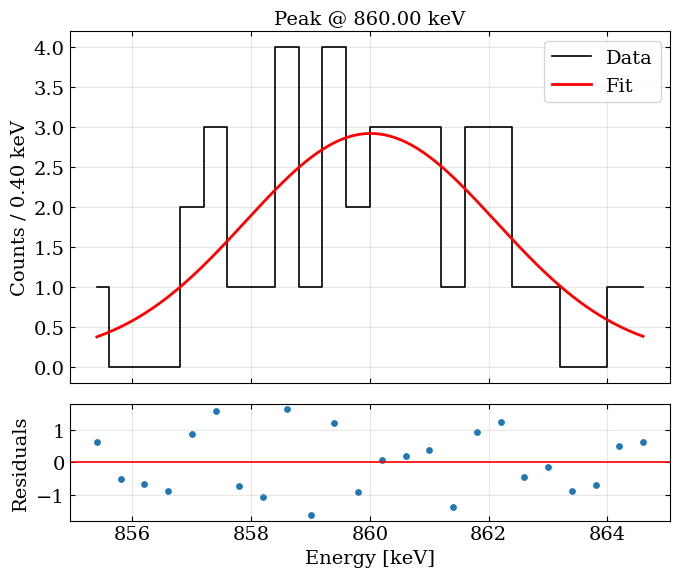

???
{'mu': np.float64(860.0116817942188), 'sigma': np.float64(2.109024135883039), 'N': np.float64(14.830091496185224), 'B': np.float64(0.11518592427095399), 'err_mu': np.float64(0.3581554869645482), 'err_sigma': np.float64(0.9957219596557425), 'err_N': np.float64(11.614272850047065), 'err_B': np.float64(1.1081984774950664)}


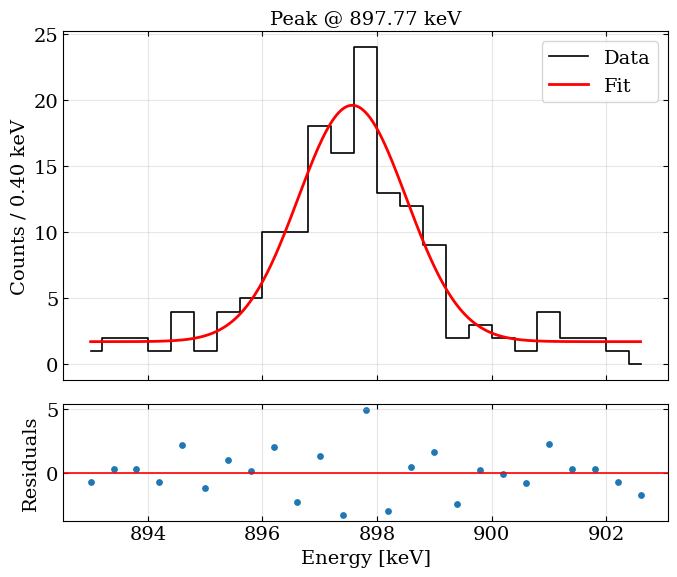

207Tl
{'mu': np.float64(897.5672926014252), 'sigma': np.float64(0.9459264090286521), 'N': np.float64(42.40055807626447), 'B': np.float64(1.7199450538473018), 'err_mu': np.float64(0.07222718959736706), 'err_sigma': np.float64(0.08352550728410978), 'err_N': np.float64(3.9770251671311114), 'err_B': np.float64(0.5607658550352896)}


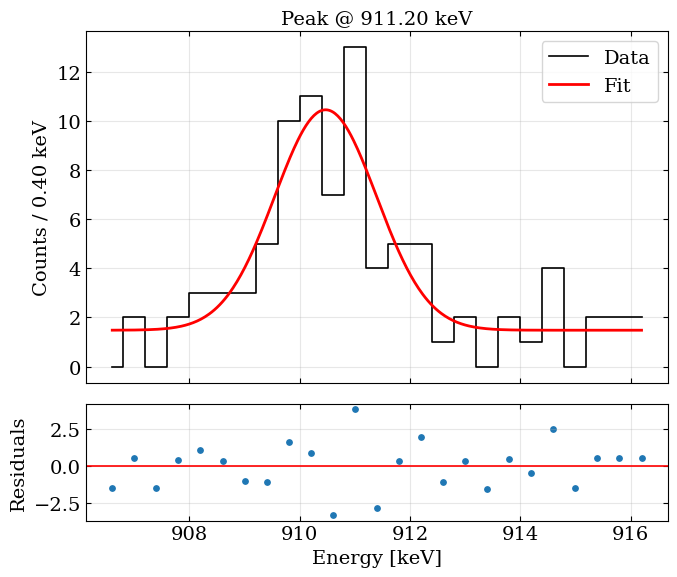

228Ac
{'mu': np.float64(910.4702837764778), 'sigma': np.float64(0.9246576300006094), 'N': np.float64(20.802899590623753), 'B': np.float64(1.4797195765319582), 'err_mu': np.float64(0.12593059373099327), 'err_sigma': np.float64(0.14480620413566606), 'err_N': np.float64(3.441159856477888), 'err_B': np.float64(0.49075672727186703)}


In [12]:
# ============================================================
# BACKGROUND PEAK FITS
# ============================================================
fit_results = {}

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    result = fit_peak(
        E_tot,
        Ntot,
        center=peak_energy,
        window=FIT_WINDOW,
        plot=True,
    )

    fit_results[peak_name] = result

    print("=" * 60)
    print(peak_name)
    print(result)

-----------

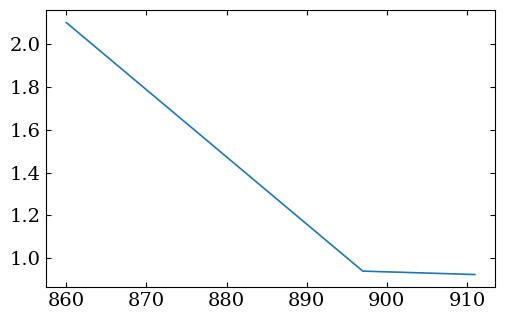

In [16]:
s = [2.10, 0.94, 0.924 ]
E = [860, 897, 911 ]
plt.plot(E, s)

# PyMC

In [13]:
# NUOVO
roi_mask = (
    (E_tot > SIGNAL["roi"][0])
    & (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

# ============================================================
# SIGNAL PDF
# ============================================================
mu_signal = SIGNAL["mu"]
sigma_signal = sigma_fun(mu_signal)

PDF_signal = norm.pdf(E_roi, mu_signal, sigma_signal)


# ============================================================
# BACKGROUND INFO
# ============================================================
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))

# valori iniziali per i sigma
background_sigmas = sigma_fun(background_energies)



In [21]:

# ============================================================
# BAYESIAN MODEL
# ============================================================
with pm.Model() as model:

    # --------------------------------------------------------
    # BACKGROUND PARAMETERS
    # --------------------------------------------------------
    A_bg = []
    mu_bg = []
    sigma_bg = []
    PDF_bg_list = []

    for peak_name in background_names:

        fit = fit_results[peak_name]

        # ------------------------
        # Amplitude prior
        # ------------------------
        A = pm.TruncatedNormal(
            f"A_{peak_name}",
            mu=fit["N"],
            sigma=max(fit["err_N"], 10.0),
            lower=0,
        )

        # ------------------------
        # Mean prior
        # ------------------------
        mu = pm.Normal(
            f"mu_{peak_name}",
            mu=fit["mu"],
            sigma=max(fit["err_mu"], 1.0),
        )

        # ------------------------
        # Sigma prior
        # ------------------------
        sigma0 = sigma_fun(fit["mu"])

        sigma = pm.TruncatedNormal(
            f"sigma_{peak_name}",
            mu=sigma0,
            sigma=max(0.2 * sigma0, 1.0),
            lower=1e-3,
        )

        # ------------------------
        # Dynamic PDF
        # ------------------------
        pdf = (
            1.0 / (sigma * np.sqrt(2 * np.pi))
        ) * pt.exp(
            -0.5 * ((E_roi - mu) / sigma) ** 2
        )

        A_bg.append(A)
        mu_bg.append(mu)
        sigma_bg.append(sigma)
        PDF_bg_list.append(pdf)

    A_bg = pt.stack(A_bg)
    mu_bg = pt.stack(mu_bg)
    sigma_bg = pt.stack(sigma_bg)

    PDF_bg = pt.stack(PDF_bg_list)

    # --------------------------------------------------------
    # SIGNAL PRIOR
    # --------------------------------------------------------
    A_signal = pm.HalfNormal(
        "A_signal",
        sigma=500,
    )

    # --------------------------------------------------------
    # FLAT BACKGROUND PRIOR
    # --------------------------------------------------------
    Q = pm.HalfNormal(
        "Q",
        sigma=500,
    )

    # --------------------------------------------------------
    # EXPECTED COUNTS
    # --------------------------------------------------------
    lambda_E = (
        Q
        + pt.sum(A_bg[:, None] * PDF_bg, axis=0)
        + A_signal * PDF_signal
    )

    # numerical stability
    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # --------------------------------------------------------
    # LIKELIHOOD
    # --------------------------------------------------------
    pm.Poisson(
        "counts_obs",
        mu=lambda_E,
        observed=counts_roi,
    )

    # --------------------------------------------------------
    # SAMPLING
    # --------------------------------------------------------
    trace = pm.sample(
        draws=SAMPLING_CONFIG["draws"],
        tune=SAMPLING_CONFIG["tune"],
        chains=SAMPLING_CONFIG["chains"],
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=SAMPLING_CONFIG["target_accept"],
        init="jitter+adapt_diag",
        return_inferencedata=True,
        progressbar=True,
    )





Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_???, mu_???, sigma_???, A_207Tl, mu_207Tl, sigma_207Tl, A_228Ac, mu_228Ac, sigma_228Ac, A_signal, Q]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.


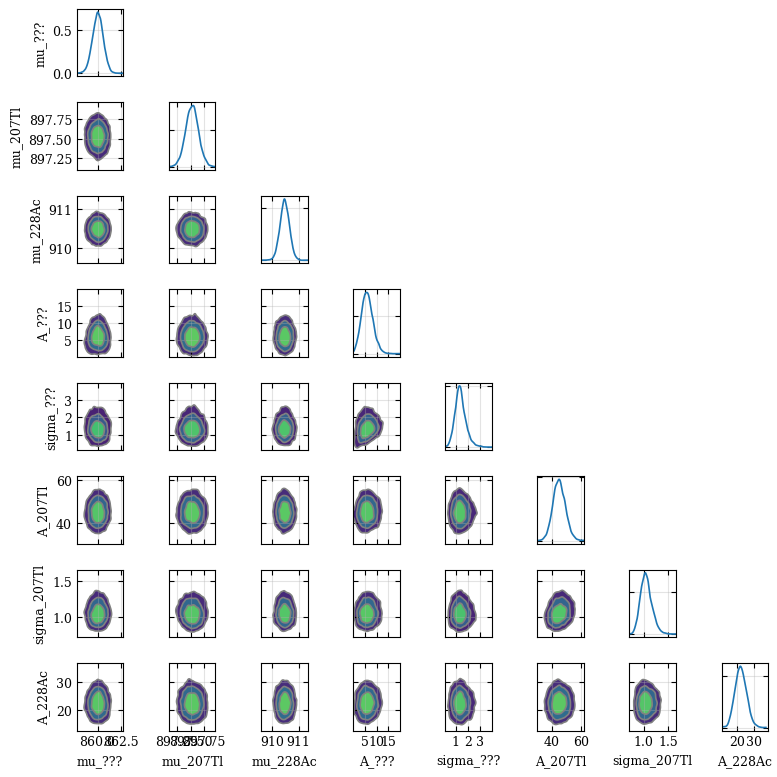

In [31]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
axes = az.plot_pair(
    trace,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [32]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 3.614
95% upper limit on signal counts : 4.281


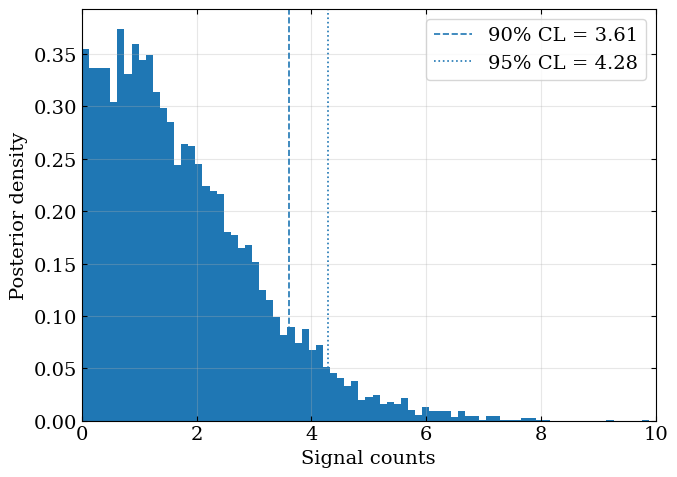

In [33]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=80, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% CL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% CL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.grid(alpha=0.3)
plt.xlim(0,10)
plt.legend()

plt.tight_layout()
plt.show()



In [34]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
mu_???: 860.03
mu_207Tl: 897.53
mu_228Ac: 910.48
A_???: 6.04
sigma_???: 1.39
A_207Tl: 45.23
sigma_207Tl: 1.05
A_228Ac: 22.35
sigma_228Ac: 1.04
A_signal: 1.77
Q: 1.26


In [35]:
sigma_fun(860)

np.float64(0.939541625388756)

In [36]:
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
background_sigmas = sigma_fun(background_energies)


In [40]:

# ============================================================
# SUMMARY
# ============================================================
summary = az.summary(trace, round_to=4)
print(summary)


# ============================================================
# POSTERIOR EXTRACTION
# ============================================================
idata = trace
posterior = idata.posterior

Q_s = posterior["Q"].values.flatten()
A_signal_s = posterior["A_signal"].values.flatten()

A_bg_s = {
    name: posterior[f"A_{name}"].values.flatten()
    for name in background_names
}

mu_bg_s = {
    name: posterior[f"mu_{name}"].values.flatten()
    for name in background_names
}

sigma_bg_s = {
    name: posterior[f"sigma_{name}"].values.flatten()
    for name in background_names
}


# ============================================================
# COSTRUZIONE λ(E) POSTERIORE
# ============================================================
lambda_samples = []
lambda_back = []

n_samples = len(Q_s)

for i in range(n_samples):

    # fondo piatto
    lam = Q_s[i] * np.ones_like(E_roi)
    lam_bkg = Q_s[i] * np.ones_like(E_roi)

    # background peaks
    for name in background_names:

        mu_i = mu_bg_s[name][i]
        sigma_i = sigma_bg_s[name][i]
        A_i = A_bg_s[name][i]

        pdf_i = norm.pdf(E_roi, mu_i, sigma_i)

        lam += A_i * pdf_i
        lam_bkg += A_i * pdf_i

    # signal
    lam += A_signal_s[i] * PDF_signal

    lambda_samples.append(lam)
    lambda_back.append(lam_bkg)

lambda_samples = np.array(lambda_samples)
lambda_back = np.array(lambda_back)


# ============================================================
# POSTERIOR STATISTICS
# ============================================================
lambda_mean = np.mean(lambda_samples, axis=0)

lambda_low = np.percentile(
    lambda_back,
    5,
    axis=0,
)

lambda_high = np.percentile(
    lambda_back,
    95,
    axis=0,
)


# ============================================================
# BACKGROUND RECONSTRUCTION
# ============================================================
posterior_means = {
    var: posterior[var].values.mean()
    for var in posterior.data_vars
}

lambda_pred_bkg = (
    posterior_means["Q"]
    * np.ones_like(E_roi)
)

for name in background_names:

    mu_mean = posterior_means[f"mu_{name}"]
    sigma_mean = posterior_means[f"sigma_{name}"]
    A_mean = posterior_means[f"A_{name}"]

    pdf_mean = norm.pdf(
        E_roi,
        mu_mean,
        sigma_mean,
    )

    lambda_pred_bkg += A_mean * pdf_mean


# ============================================================
# 90% SIGNAL UPPER LIMIT
# ============================================================
N_signal_90 = np.percentile(
    A_signal_s,
    90,
)

lambda_pred = (
    lambda_pred_bkg
    + N_signal_90 * PDF_signal
)


                 mean      sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
mu_???       860.0320  0.5808  858.9832  861.1528     0.0061   0.0075   
mu_207Tl     897.5284  0.1184  897.2946  897.7460     0.0012   0.0014   
mu_228Ac     910.4751  0.1758  910.1499  910.8038     0.0020   0.0021   
A_???          6.0376  2.4357    1.7152   10.8467     0.0316   0.0308   
sigma_???      1.3947  0.4545    0.5686    2.2675     0.0059   0.0065   
A_207Tl       45.2275  4.1960   37.4293   53.1149     0.0505   0.0460   
sigma_207Tl    1.0520  0.1151    0.8369    1.2632     0.0014   0.0014   
A_228Ac       22.3487  3.3107   16.1049   28.4126     0.0352   0.0358   
sigma_228Ac    1.0361  0.1581    0.7376    1.3270     0.0019   0.0021   
A_signal       1.7680  1.3307    0.0011    4.1216     0.0143   0.0166   
Q              1.2628  0.0956    1.0879    1.4463     0.0011   0.0010   

              ess_bulk   ess_tail   r_hat  
mu_???       9197.5565  5505.0963  1.0003  
mu_207Tl     9624.1427  5589.3303  

In [41]:
# ============================================================
# RESIDUALS
# ============================================================
residuals = counts_roi - lambda_mean


# ============================================================
# OPTIONAL: PRINT RESULTS
# ============================================================
print("\n==============================")
print("RESULTS")
print("==============================")

print(f"Signal 90% UL = {N_signal_90:.3f}")

for name in background_names:
    print(
        f"{name}: "
        f"A = {posterior_means[f'A_{name}']:.3f}, "
        f"mu = {posterior_means[f'mu_{name}']:.3f}, "
        f"sigma = {posterior_means[f'sigma_{name}']:.3f}"
    )


RESULTS
Signal 90% UL = 3.614
???: A = 6.038, mu = 860.032, sigma = 1.395
207Tl: A = 45.227, mu = 897.528, sigma = 1.052
228Ac: A = 22.349, mu = 910.475, sigma = 1.036


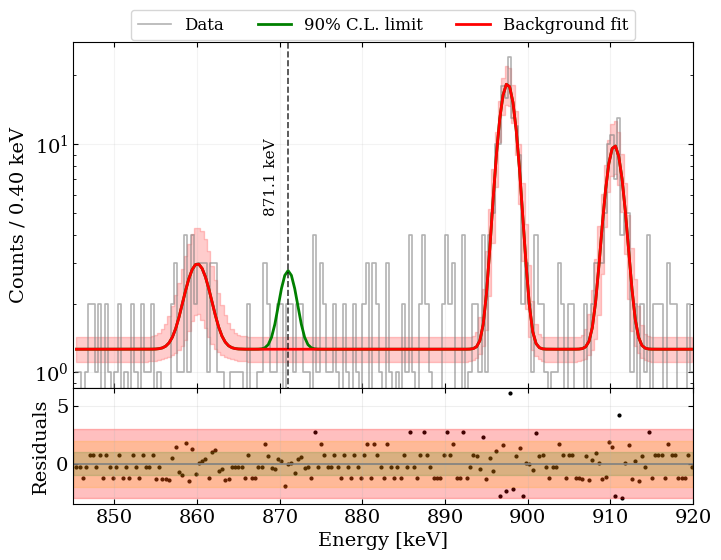

In [42]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# =========================
# PLOT SUPERIORE
# =========================
ax1.step(E_roi, counts_roi, where='mid', color='grey', alpha=0.6, label='Data')


ax1.plot(E_roi, lambda_pred, color='green', lw=2, label='90% C.L. limit')
ax1.plot(E_roi, lambda_pred_bkg, color='red', lw=2, label='Background fit')

ax1.fill_between(E_roi, lambda_low, lambda_high,
                 color='red', alpha=0.2, step='mid')

ax1.set_yscale('log')
ax1.set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
ax1.grid(alpha=0.15)
ax1.annotate(
    "871.1 keV",
    xy=(871.1 - 3, 5),
    rotation=90,
    fontsize=11
)
ax1.vlines(871, 0, 30, ls='--', color='black', alpha=0.75)
ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=12
)


# =========================
# PLOT INFERIORE (RESIDUI)
# =========================
ax2.scatter(E_roi, residuals, s=4, color='black')


ax2.axhspan(-3, 3, color='red', alpha=0.25)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)


ax2.axhline(0, color='gray')
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.2)
ax1.set_xlim(845, 920)

plt.subplots_adjust(hspace=0)
plt.show()


In [23]:

# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_94Zr = 0.0294935    # efficienza di rivelazione
i_a_94Zr = 0.1738       # abbondanza isotopica
t_live =    t_tot/(60*60*24*365)             # 90 giorni in anni

# Posterior del numero di eventi segnale
signal_samples = trace.posterior['A_signal'].values.flatten()

# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_94Zr / Mr_sample) * N_A

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_94Zr * t_live) / np.percentile(signal_samples, percentile)
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 6.09e+20 yrs at 90%


In [24]:
m_sample * i_a_94Zr * t_tot # gr * s
m_sample * i_a_94Zr * 0.001 * ( t_tot/(60*60) )


189.1578858136611